# Instructions

**Please follow these instructions carefully to ensure your submission is graded correctly:**

- Fill in **your answers** in any place that says "YOUR CODE HERE" or "YOUR ANSWER HERE" in the provided `.ipynb` files.

- Do not use print statements or the variable name `_` to display your answers; instead, make sure the last line of the cell contains the variable that holds your answer.

- Your answers to code-based questions must be **generated from code**. Hardcoded answers will result in a deduction of points.  

- Do not change the **autograding cells** labelled with `"AUTOGRADING CELL - DO NOT TOUCH!"`. Modifying or deleting them may lead to incorrect grading results.

- All plots must have appropriate **axis labels** including units where applicable. Failing to do so will result in a partial deduction of points.

- Always proide **units** for quantities where applicable. Failing to do so will result in a partial deduction of points.

- The **code quality** will not be graded. However, concise, well-structured code makes it easier to awared partial points in case of errors.

- The quality of **written answers** and **figures** will be considered during grading.

- Do not use additional packages that are not part of the course **environment**. This would lead to errors during autograding.

- Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel $\rightarrow$ Restart) and then **run all cells** (in the menubar, select Cell $\rightarrow$ Run All).

- Submissions must be your own work, **plagiarism** from the web or peers will be checked for and sanctioned.

- Please upload only the provided `.ipynb` files, filled in with your answers.

- Please **do not** put the `.ipynb` files into archives (e.g., `.zip`, `.tar.gz`); also `.py` files will **not** be accepted. Please **do not change the file names** and do not upload additional files.

- Submission on ISIS *(for TU Berlin students)* requires **two-factor authentication**.

---

## Task 4: Investment Optimisation (26 points)

**In this task you are asked to perform some sensitivity analysis in the field of investment optimisation.**

You are provided with a simple PyPSA network (`n = pypsa.examples.model_energy()`). This network contains is for a single region with load time series, a battery, as well as wind and solar generators with capacity factor time series. It has an electricity bus and a hydrogen bus with underground storage, which are connected by an electrolyser and a hydrogen turbine. There is also a high variable cost load shedding option. The network is set up to allow for capacity expansion in all components.

More information on the network can be found in the [PyPSA documentation](https://docs.pypsa.org/latest/examples/capacity-expansion-planning-single-node/).

In [1]:
!pip install pypsa

In [2]:
import pypsa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pypsa.options.params.optimize.solver_name = "highs"
pypsa.options.params.optimize.solver_options = {"LogToConsole": 0}

n = pypsa.examples.model_energy()

**a)** Calculate the annuitised capital cost (in €/MW/a) of a nuclear power plant with an overnight investment cost of 10,000 €/kW, a lifetime of 40 years and a discount rate of 7.5%. Return the result as a float. **(2 points)**

In [3]:
from pypsa.costs import annuity
overnight_cost = 10000  # €/kW
capital_cost = overnight_cost * 1000 * annuity(0.075, 40)
capital_cost #€/MWh

794003.1380297343

In [4]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)

**b)** Add the option for building a new nuclear power plant to the network named `"nuclear"`. The generator should use the capital cost calculated in (a) and a marginal cost of 20 €/MWh electricity, covering fuel and maintenance costs. Additionally, consider that the nuclear power plant is inflexible with a minimum partial load of 90%. **(2 points)**

In [5]:
n.add("Generator","nuclear",bus="electricity",carrier="nuclear",capital_cost=capital_cost,marginal_cost=20,p_nom_extendable=True,p_min_pu=0.9,)

In [6]:
### AUTOGRADING CELL - DO NOT TOUCH!

In [7]:
### AUTOGRADING CELL - DO NOT TOUCH!

In [8]:
### AUTOGRADING CELL - DO NOT TOUCH!

In [9]:
### AUTOGRADING CELL - DO NOT TOUCH!

**Now, perform a sensitivity analysis on the capital cost of the nuclear power plant. Vary the capital cost between 2,000 €/kW and 12,000 €/kW and answer the questions below.**

In [10]:
overnight_costs = np.arange(2000, 12001, 1000)

system_costs = {}
nuclear_shares = {}
nuclear_cost_shares = {}
nuclear_avg_generation = {}

for overnight_cost in overnight_costs:

    n = pypsa.examples.model_energy()

    capital_cost = overnight_cost * 1000 * annuity(0.075, 40)

    n.add("Carrier", "nuclear", overwrite=True)
    n.add("Generator","nuclear",bus="electricity",carrier="nuclear",capital_cost=capital_cost,marginal_cost=20,p_nom_extendable=True,p_min_pu=0.9, )

    n.optimize()

    total_cost = n.statistics.capex().sum() + n.statistics.opex().sum() #per year
    system_costs[overnight_cost] = total_cost / 1e9 #billion euros per year

    nuclear_avg_generation[overnight_cost] = (n.generators_t.p["nuclear"].mean()).copy() #to check the model

    nuclear_generation = n.generators_t.p["nuclear"].sum()
    total_generation = n.generators_t.p.sum().sum()
    nuclear_shares[overnight_cost] = 100 * nuclear_generation / total_generation

    nuclear_capital_cost = (n.generators.loc["nuclear", "capital_cost"]* n.generators.loc["nuclear", "p_nom_opt"])
    nuclear_marginal_cost = (n.generators_t.p["nuclear"].sum()* n.generators.loc["nuclear", "marginal_cost"])
    nuclear_cost = nuclear_capital_cost + nuclear_marginal_cost
    nuclear_cost_shares[overnight_cost] = 100 * nuclear_cost / total_cost

/tmp/ipykernel_15883/2481322341.py:17: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Writing continuous variables.: 100%|██████████| 11/11 [00:00<00:00, 215.40it/s]
/tmp/ipykernel_15883/2481322341.py:17: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Writing continuous variables.: 100%|██████████| 11/11 [00:00<00:00, 247.93it/s]
/tmp/ipykernel_15883/2481322341.py:17: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` expli

**c)** How do total system costs change as a function of nuclear investment costs? Provide the answer as a `pandas.Series` with the overnight investment cost (in €/kW) as the index and the total system cost (in billion € per year) as the values in order of ascending costs. **(2 points)**

In [11]:
system_cost_series = pd.Series(system_costs)
system_cost_series #in billion € per year

,0
2000,3.727202
3000,4.405022
4000,5.019778
5000,5.621936
6000,6.199973
7000,6.752938
8000,7.282243
9000,7.754882
10000,8.071785
11000,8.078136


In [12]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, pd.Series)

**d)** How does the contribution of nuclear power to the electricity mix change as a function of nuclear investment costs? Provide the answer as a `pandas.Series` with the overnight investment cost (in €/kW) as the index and the nuclear power contribution (in % of total electricity generated) as the values in order of ascending costs. **(2 points)**

In [13]:
nuclear_share_series = pd.Series(nuclear_shares)
nuclear_share_series

,0
2000,99.943621
3000,93.267772
4000,90.096904
5000,88.243621
6000,83.367619
7000,80.797161
8000,75.037396
9000,61.659731
10000,16.660440
11000,0.000000


In [14]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, pd.Series)

**e)** How does the share of nuclear power in total system cost change as a function of nuclear investment costs? Provide the answer as a `pandas.Series` with the overnight investment cost (in €/kW) as the index and the nuclear power contribution (in % of total system cost) as the values in order of ascending costs. **(2 points)**

In [15]:
nuclear_cost_share_series = pd.Series(nuclear_cost_shares)
nuclear_cost_share_series

,0
2000,51.320534
3000,52.772404
4000,56.746735
5000,60.181865
6000,60.640258
7000,61.846237
8000,60.569112
9000,53.009154
10000,15.971633
11000,0.000000


In [16]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, pd.Series)

**f)** Plot the three `pandas.Series` created in parts (c), (d), and (e) in a single figure with three subplots and shared x-axis. **(2 points)**

array([<Axes: title={'center': 'Impact of Nuclear Investment Cost on Total System Cost'}, xlabel='Overnight investment cost (€/kW)', ylabel='System cost\n(billion €/year)'>,
       <Axes: title={'center': 'Share of Nuclear in Energy Mix'}, xlabel='Overnight investment cost (€/kW)', ylabel='Nuclear generation\nshare (%)'>,
       <Axes: title={'center': 'Nuclear Contribution to Total System Cost'}, xlabel='Overnight investment cost (€/kW)', ylabel='Nuclear cost\nshare (%)'>],
      dtype=object)

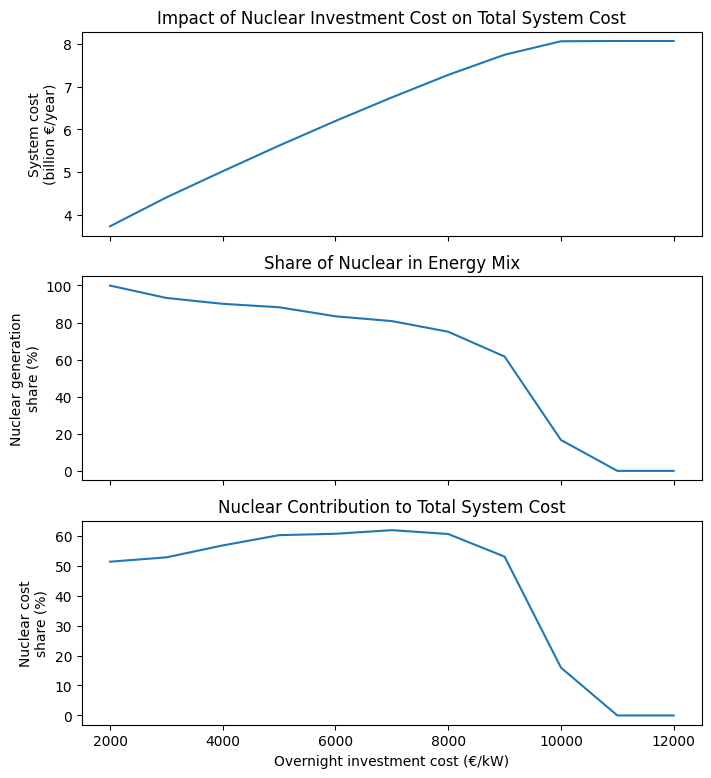

In [17]:
fig, ax = plt.subplots(3, 1, figsize=(8, 9),sharex=True)

system_cost_series.plot(ax=ax[0])
ax[0].set_ylabel("System cost\n(billion €/year)")
ax[0].set_xlabel("Overnight investment cost (€/kW)")
ax[0].set_title("Impact of Nuclear Investment Cost on Total System Cost")

nuclear_share_series.plot(ax=ax[1])
ax[1].set_ylabel("Nuclear generation\nshare (%)")
ax[1].set_xlabel("Overnight investment cost (€/kW)")
ax[1].set_title("Share of Nuclear in Energy Mix")

nuclear_cost_share_series.plot(ax=ax[2])
ax[2].set_ylabel("Nuclear cost\nshare (%)")
ax[2].set_xlabel("Overnight investment cost (€/kW)")
ax[2].set_title("Nuclear Contribution to Total System Cost")

ax

**In the following, we start with a newly loaded base network without the nuclear power plant option. Now, you are asked to evaluate the potential role of a new technology in this stylised energy system: an [iron-air battery](https://formenergy.com/technology/battery-technology/).**

In [18]:
n = pypsa.examples.model_energy()
n.optimize()
base_cost = n.statistics.capex().sum() + n.statistics.opex().sum()

/tmp/ipykernel_15883/431519308.py:2: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Writing continuous variables.: 100%|██████████| 11/11 [00:00<00:00, 303.48it/s]


**g)** Calculate the annuitised capital cost (in €/MW/a power capacity) of the iron-air battery, assuming overnight investment cost of 20,000 €/kWh, a lifetime of 20 years, a discount rate of 7.5%, and an energy-to-power ratio of 100 hours. Return the result as a float. **(2 points)**

In [19]:
overnight_cost_iron_air = 20000 #€/MWh
annuity(0.075, 20)
capital_cost_iron_air = (
    overnight_cost_iron_air
    * 100           # 100 h E/P ratio
    * annuity(0.075, 20))
capital_cost_iron_air #€/MW

196184.38326466284

In [20]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)

**h)** Add the option for building an iron-air battery as a `StorageUnit` named `"iron-air"` and optimise the network. The storage unit should use the capital cost calculated in (f), a discharge efficiency of 70%, a charging efficiency of 60%. Additionally, consider that the storage unit should be cyclic within the year. **(2 points)**

In [21]:
n.add(
    "StorageUnit",
    "iron-air",
    bus="electricity",
    carrier="iron-air",
    capital_cost=capital_cost_iron_air,
    efficiency_store=0.60,
    efficiency_dispatch=0.70,
    p_nom_extendable=True,
    max_hours=100,
    cyclic_state_of_charge=True,
    overwrite=True,)

n.optimize()

/tmp/ipykernel_15883/966478902.py:14: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['iron-air'], dtype='object', name='name')
Writing continuous variables.: 100%|██████████| 11/11 [00:00<00:00, 278.94it/s]


('ok', 'optimal')

In [22]:
### AUTOGRADING CELL - DO NOT TOUCH!

In [23]:
### AUTOGRADING CELL - DO NOT TOUCH!

In [24]:
### AUTOGRADING CELL - DO NOT TOUCH!

In [25]:
### AUTOGRADING CELL - DO NOT TOUCH!

**i)** By how many percent does the total system cost reduce when the iron-air battery is added? Return the result as a float (in %). **(2 points)**

In [26]:
iron_air_cost = n.statistics.capex().sum() + n.statistics.opex().sum()

cost_reduction = 100 * (base_cost - iron_air_cost) / base_cost

float(cost_reduction) # %

14.337133141705282

In [27]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)

**j)** What share of capital expenditures (in percent) is attributed to balancing technologies (i.e. everything but wind and solar generation). Return the result as a float. **(2 points)**

In [28]:
capex = n.statistics.capex()

balancing_capex = capex.drop(
    ["wind", "solar"],
    level="carrier"
).sum()

total_capex = capex.sum()

balancing_share = 100 * balancing_capex / total_capex

float(balancing_share) # %

31.6877808961872

In [29]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)

**k)** What is the optimised energy capacity of the iron-air battery (in TWh)? Return the result as a float. **(2 points)**

In [30]:
energy_capacity = abs(n.storage_units.loc["iron-air", "p_nom_opt"]* n.storage_units.loc["iron-air", "max_hours"]) / 1e6
float(energy_capacity) #TWh

1.0125684612484882

In [31]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)

**l)** Plot the full-year state-of-charge profile of the iron-air battery (in TWh). **(2 points)**

<Axes: title={'center': 'Iron-Air Battery State of Charge During the Year (2019)'}, xlabel='Time', ylabel='State of Charge (TWh)'>

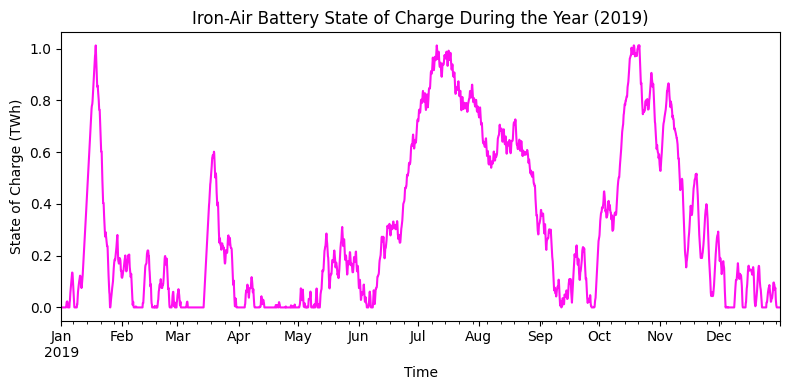

In [32]:
iron_air_soc = n.storage_units_t.state_of_charge["iron-air"] / 1e6

ax = iron_air_soc.plot(figsize=(8, 4), color="#FF10F0")

ax.set_title("Iron-Air Battery State of Charge During the Year (2019)")
ax.set_xlabel("Time")
ax.set_ylabel("State of Charge (TWh)")

plt.tight_layout()
ax

**m)** How much energy (in TWh) is lost in the iron-air battery due to conversion inefficiencies? Return the result as a float. **(2 points)**

In [33]:
charge = -n.storage_units_t.p["iron-air"][n.storage_units_t.p["iron-air"] < 0].sum()

discharge = n.storage_units_t.p["iron-air"][n.storage_units_t.p["iron-air"] > 0].sum()

energy_loss = (charge - discharge) / 1e6

float(energy_loss) #TWh

4.162204725644504

In [34]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)